In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Autoencoder

- type of neural network which learns lower dimensional data representation

- used for dimensionality reduction, noise reduction etc.

- unsupervised model because it minimizes the reconstruction error, standard output labels are not used

![Autoencoder](../img/autoencoder.png)

source: https://towardsdatascience.com/applied-deep-learning-part-3-autoencoders-1c083af4d798

# Loading Fashion MNIST dataset

In [2]:
from dlfs.helpers import DLFSData

fashion_path = "../data/fashion_mnist"
X_train, y_train, X_test, y_test = DLFSData.FashionMNIST.load_fashion_MNIST(fashion_path, from_ubyte=True)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (60000, 28, 28), X_test: (10000, 28, 28)


In [3]:
X_train = DLFSData.normalize_images(X_train, range=(0, 1)).reshape(-1, 1, 28, 28)
X_test = DLFSData.normalize_images(X_test, range=(0, 1)).reshape(-1, 1, 28, 28)

X_train, _ = DLFSData.select_image_labels(X_train, y_train, labels=[0, 2, 4, 6], limit=2500)
X_test, _ = DLFSData.select_image_labels(X_test, y_test, labels=[0, 2, 4, 6], limit=500)

print(f'Train: {X_train.shape}\nTest: {X_test.shape}')

Train: (10000, 1, 28, 28)
Test: (2000, 1, 28, 28)


# Autoencoder for reconstructing original image

In [4]:
from dlfs.layers import DenseLayer, ReshapeLayer
from dlfs.activation import ReLU, Sigmoid
from dlfs.model import SequentialModel
from dlfs.modules import SequentialWrapper
from dlfs.loss import MSE_Loss
from dlfs.optimizers import Optimizer_Adam

latent_dim = 256

encoder_layers = [
    ReshapeLayer(input_shape=(1, 28, 28), output_shape=(1*28*28, )),
    DenseLayer(28*28, 4*latent_dim),
    ReLU(),
    DenseLayer(4*latent_dim, latent_dim)
]

decoder_layers = [
    DenseLayer(latent_dim, 4*latent_dim),
    ReLU(),
    DenseLayer(4*latent_dim, 28*28),
    Sigmoid(),
    ReshapeLayer(input_shape=(1*28*28, ), output_shape=(1, 28, 28))
]

enc = SequentialWrapper(encoder_layers)
dec = SequentialWrapper(decoder_layers)

layers = [enc, dec]

lr = 3e-3

model = SequentialModel(layers=layers, loss_function=MSE_Loss(), optimizer=Optimizer_Adam(learning_rate=lr))
model.train(X_train, X_train, print_every=40, batch_size=1000, epochs=200)

===== EPOCH : 0 ===== LOSS : 0.07461 =====
===== EPOCH : 40 ===== LOSS : 0.02394 =====
===== EPOCH : 80 ===== LOSS : 0.01198 =====
===== EPOCH : 120 ===== LOSS : 0.00997 =====
===== EPOCH : 160 ===== LOSS : 0.00860 =====
===== EPOCH : 200 ===== LOSS : 0.00777 =====


# Random image from test set

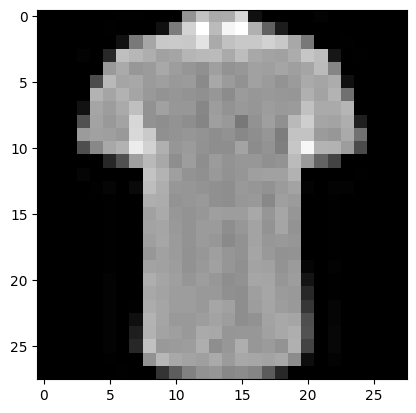

In [8]:
idx = np.random.randint(0, len(X_test))

test_img = X_test[idx]
plt.imshow(test_img.reshape(28, 28), cmap='gray')
plt.show()

# Compressing image to latent space using encoder

In [9]:
enc.forward(test_img, training=False)
compressed = enc.output
print(f'Compressed shape: {compressed.shape}')

Compressed shape: (1, 256)


# Restoring image from compressed state using decoder

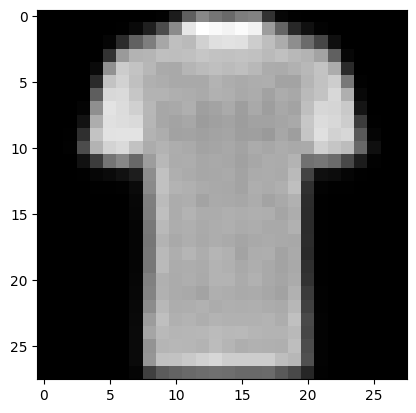

In [10]:
dec.forward(compressed, training=False)
decompressed = DLFSData.denormalize_images(dec.output, range=(0, 1))
plt.imshow(decompressed.reshape(28, 28), cmap='gray')
plt.show()

# Autoencoder for denoising images

In [11]:
def salt_pepper_noise(image, salt_prob, pepper_prob):
    """
    Adds salt and pepper noise to image.
    """

    if len(image.shape) == 2:

        num_salt = np.ceil(salt_prob * image.shape[0] * image.shape[1])
        num_pepper = np.ceil(pepper_prob * image.shape[0] * image.shape[1])

        salt_cords = [np.random.randint(0, i, int(num_salt)) for i in image.shape]
        pepper_cords = [np.random.randint(0, i, int(num_pepper)) for i in image.shape]

        output = image.copy()

        output[tuple(salt_cords)] = 1
        output[tuple(pepper_cords)] = 0

    elif len(image.shape) == 3:

        num_salt = np.ceil(salt_prob * image.shape[1] * image.shape[2])
        num_pepper = np.ceil(pepper_prob * image.shape[1] * image.shape[2])

        salt_cords = [np.random.randint(0, i, int(num_salt)) for i in image.shape[1:]]
        pepper_cords = [np.random.randint(0, i, int(num_pepper)) for i in image.shape[1:]]

        output = image.copy()

        output[:, salt_cords[0], salt_cords[1]] = 1
        output[:, pepper_cords[0], pepper_cords[1]] = 0

    return output

In [12]:
X_train_noisy = []
X_test_noisy = []

for img in X_train:
    noisy_img = salt_pepper_noise(img, salt_prob=0.1, pepper_prob=0.01)
    X_train_noisy.append(noisy_img)

for img in X_test:
    noisy_img = salt_pepper_noise(img, salt_prob=0.1, pepper_prob=0.01)
    X_test_noisy.append(noisy_img)

X_train_noisy = np.array(X_train_noisy)
X_test_noisy = np.array(X_test_noisy)
print(f'Train noisy: {X_train_noisy.shape}\nTest noisy: {X_test_noisy.shape}')

Train noisy: (10000, 1, 28, 28)
Test noisy: (2000, 1, 28, 28)


In [13]:
from dlfs.layers import DenseLayer, ReshapeLayer
from dlfs.activation import ReLU, Sigmoid
from dlfs.loss import BCE_Loss
from dlfs.optimizers import Optimizer_Adam

latent_dim = 256

encoder_layers = [
    ReshapeLayer(input_shape=(1, 28, 28), output_shape=(1*28*28, )),
    DenseLayer(28*28, 4*latent_dim),
    ReLU(),
    DenseLayer(4*latent_dim, latent_dim)
]

decoder_layers = [
    DenseLayer(latent_dim, 4*latent_dim),
    ReLU(),
    DenseLayer(4*latent_dim, 28*28),
    Sigmoid(),
    ReshapeLayer(input_shape=(1*28*28, ), output_shape=(1, 28, 28))
]

enc = SequentialWrapper(encoder_layers)
dec = SequentialWrapper(decoder_layers)

layers = [enc, dec]

lr = 1e-3

model = SequentialModel(layers=layers, loss_function=MSE_Loss(), optimizer=Optimizer_Adam(learning_rate=lr))
model.train(X_train_noisy, X_train, print_every=40, batch_size=1000, epochs=200)

===== EPOCH : 0 ===== LOSS : 0.07396 =====
===== EPOCH : 40 ===== LOSS : 0.01854 =====
===== EPOCH : 80 ===== LOSS : 0.01252 =====
===== EPOCH : 120 ===== LOSS : 0.01112 =====
===== EPOCH : 160 ===== LOSS : 0.01046 =====
===== EPOCH : 200 ===== LOSS : 0.00836 =====


# Using autoencoder to denoise an image

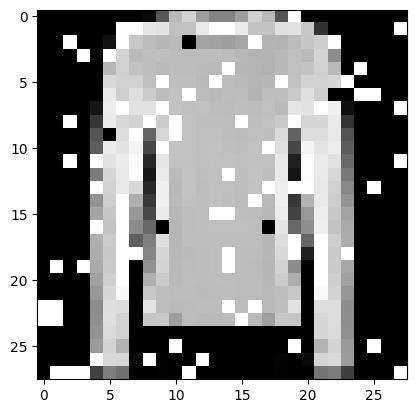

In [14]:
idx = np.random.randint(0, len(X_test))

noisy_img = X_test_noisy[idx]
plt.imshow(noisy_img.reshape(28, 28), cmap='gray')
plt.show()

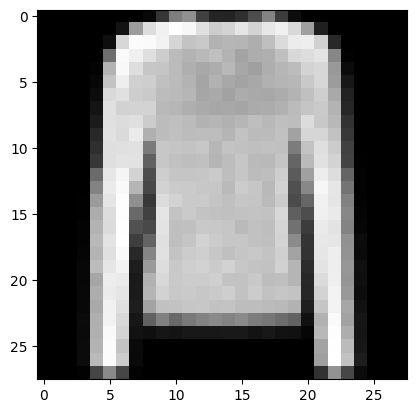

In [15]:
corrected = model.predict(noisy_img)
plt.imshow(corrected.reshape(28, 28), cmap='gray')
plt.show()